In [1]:
from module import *

In [2]:
table_info("hr24")

nrows: 1154681
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      5 non-null      float64
 1   date    5 non-null      str    
 2   value   5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,id,date,value
0,2.022484e+09,2016-04-01 07:54:00,93
1,2.022484e+09,2016-04-01 07:54:05,91
2,2.022484e+09,2016-04-01 07:54:10,96
3,2.022484e+09,2016-04-01 07:54:15,98
4,2.022484e+09,2016-04-01 07:54:20,100


In [3]:
df = pd.read_sql("""
                SELECT
                    STRFTIME('%H', date) AS time,
                    id,
                    COUNT(*) AS count,
                    AVG(value) AS mean,
                    stdev(value) AS stdev,
                    MIN(value) AS min,
                    percentile(value, 0.25) AS p25,
                    percentile(value, 0.5) AS median,
                    percentile(value, 0.75) AS p75,
                    MAX(value) AS max
                FROM hr24
                GROUP BY time, id
                ORDER BY time, id
                """, conn)
df['time'] = df['time'].astype(int)
df

,time,id,count,mean,stdev,min,p25,median,p75,max
0,0,2.026352e+09,258,62.263566,1.988368,57,61.0,62.0,63.0,68
1,0,2.347168e+09,3936,69.943598,6.300592,56,66.0,70.0,74.0,89
2,0,4.020333e+09,8832,77.099864,12.450231,56,67.0,74.0,88.0,108
3,0,4.558610e+09,1457,70.377488,8.621242,55,64.0,69.0,75.0,118
4,0,5.553957e+09,3764,60.211211,5.606626,50,56.0,59.0,63.0,83
...,...,...,...,...,...,...,...,...,...,...
285,23,6.391747e+09,336,84.354167,3.192741,76,82.0,84.0,87.0,94
286,23,6.775889e+09,1485,94.580471,10.491546,76,85.0,94.0,103.0,121
287,23,6.962181e+09,4353,70.076269,6.334224,55,66.0,69.0,73.0,98
288,23,8.792010e+09,2138,75.064546,6.518865,61,71.0,74.0,78.0,111


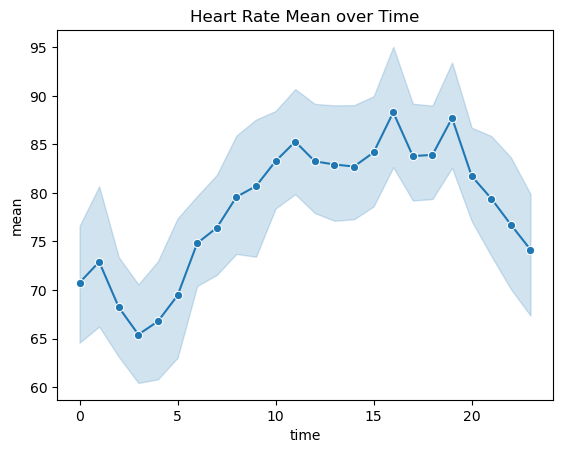

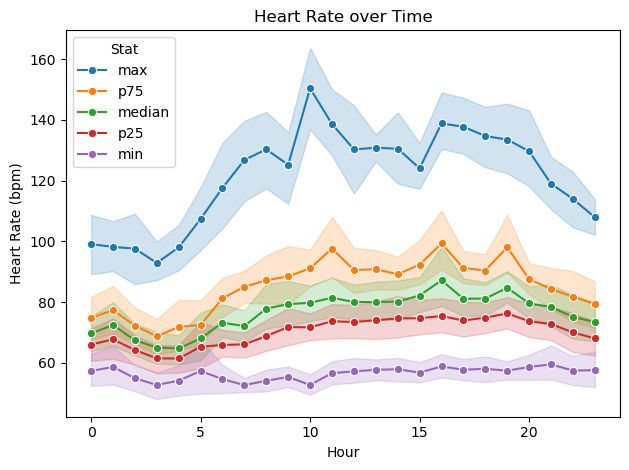

In [5]:
melt = df.melt(
        id_vars=['time'],
        value_vars=['min', 'p25', 'median', 'p75', 'max'][::-1],
        var_name='stat',
        value_name='heart_rate'
)

sns.lineplot(df, x='time', y='mean', marker='o')
plt.title("Heart Rate Mean over Time")
plt.show()

sns.lineplot(data=melt, x='time', y='heart_rate', hue='stat', marker='o')
plt.xlabel('Hour')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate over Time')
plt.legend(title='Stat')
plt.tight_layout()
plt.show()